In [1]:
# Set working directory
import os
os.chdir("../../")

In [2]:
# Configure file paths and load with pandas
import pandas as pd

# Extracted footprints and nucleosome scores (see analysis code for calculation)
erg_fp_df = pd.read_csv("../Experimental_data_analysis/fimo_footprints/hocomoco_default_pthreshold/individual_hoco_motif/raw_signals/ERG_raw_windows.csv", index_col=0)
erg_nuc_df = pd.read_csv("../Experimental_data_analysis/fimo_footprints/hocomoco_default_pthreshold/individual_hoco_motif/nuc_scores/ERG_nucleosome_windows.csv", index_col=0)

atf1_fp_df = pd.read_csv("../Experimental_data_analysis/fimo_footprints/hocomoco_default_pthreshold/individual_hoco_motif/raw_signals/ATF1_raw_windows.csv", index_col=0)
atf1_nuc_df = pd.read_csv("../Experimental_data_analysis/fimo_footprints/hocomoco_default_pthreshold/individual_hoco_motif/nuc_scores/ATF1_nucleosome_windows.csv", index_col=0)

## Imports

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from typing import Optional, Sequence, Tuple

## Plot

In [4]:
def plot_nuc_with_binding(
    nuc_df: pd.DataFrame,
    bind_df: pd.DataFrame,
    *,
    width: int = 100,
    rows: Optional[int] = None,
    figsize: Tuple[float, float] = (12, 6),
    interpolation: str = "nearest",
    cmap: str = "Blues",
    dropna: bool = False,
    suptitle: Optional[str] = None,
) -> plt.Figure:

    # Columns for plotting nucleosome score
    heat_cols = [f"pos_{i}" for i in range(-width, width + 1)
                 if f"pos_{i}" in nuc_df.columns]

    # Columns for sorting by binding strength
    sort_cols = [f"pos_{i}" for i in range(-25, 26)
                 if f"pos_{i}" in bind_df.columns]

    # Optional NA filtering
    if dropna:
        valid_idx = (
            nuc_df[heat_cols].dropna().index
            .intersection(bind_df[sort_cols].dropna().index)
        )
        nuc_df = nuc_df.loc[valid_idx]
        bind_df = bind_df.loc[valid_idx]

    # Sort rows by binding strength
    order = bind_df[sort_cols].sum(axis=1).sort_values(ascending=False).index
    n = len(order) if rows is None else min(rows, len(order))
    order = order[:n]

    data_nuc = nuc_df.loc[order, heat_cols].to_numpy()

    # --- Plot ---
    fig, ax = plt.subplots(figsize=figsize)

    im = ax.imshow(
        data_nuc,
        aspect="auto",
        interpolation=interpolation,
        cmap=cmap,
        vmax=1
    )

    # Mark motif center
    if "pos_0" in heat_cols:
        ax.axvline(
            x=heat_cols.index("pos_0"),
            color="white",
            linestyle="--",
            linewidth=1.2,
            alpha=0.6
        )

    # X ticks
    if heat_cols:
        ncols = len(heat_cols)
        xs = np.linspace(0, ncols - 1, num=min(ncols, 5), dtype=int)
        ax.set_xticks(xs)
        ax.set_xticklabels([int(heat_cols[i].split("_", 1)[1]) for i in xs])

    ax.set_xlabel("Distance from motif (bp)", fontsize=11)
    # ax.set_title("Nucleosome score", fontsize=12)

    ax.tick_params(axis="y", left=False, labelleft=False)

    # --- Colorbar (does NOT resize heatmap) ---
    pos = ax.get_position()

    cax = fig.add_axes([
        pos.x1 + 0.07,   # horizontal gap from heatmap
        pos.y0,          # same bottom
        0.07,           # <-- colorbar width (increase this!)
        pos.height       # same height as heatmap
    ])

    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label("Nucleosome score", rotation=270, labelpad=14, fontsize=11)
    cbar.ax.tick_params(labelsize=10)

    # Optional suptitle
    if suptitle:
        fig.suptitle(suptitle, fontsize=15, y=0.95)

    return fig

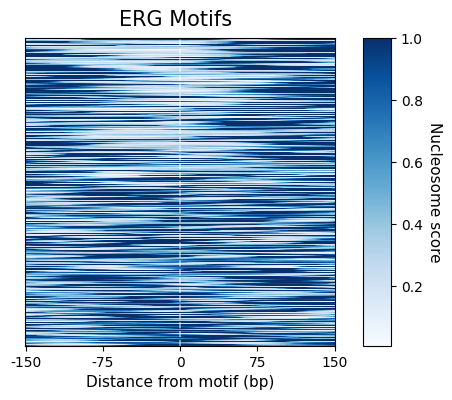

In [5]:
fig1 = plot_nuc_with_binding(
    nuc_df=erg_nuc_df,
    bind_df=erg_fp_df,
    width = 150,
    figsize = (4, 4),
    dropna=True,
    suptitle="ERG Motifs"
)

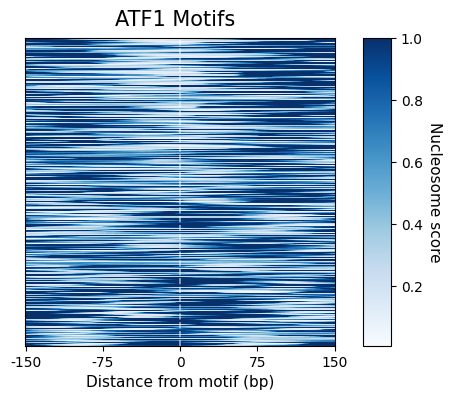

In [6]:
fig2 = plot_nuc_with_binding(
    nuc_df=atf1_nuc_df,
    bind_df=atf1_fp_df,
    width = 150,
    figsize = (4, 4),
    dropna=True,
    suptitle="ATF1 Motifs"
)